# Animation

Because pyplotrs has no global "current figure" to mutate, an animation cannot
be a sequence of edits to one plot. It is a **render callback**: a function
that is handed a frame value and returns a fully-built `Figure`, called once
per frame.

That is a smaller idea than matplotlib's `FuncAnimation`, and it removes the
part that is usually the bug — there is no artist to fetch and update, no
`blit` to reason about, and no state left over from the previous frame. Every
frame is an ordinary figure, built the ordinary way.

It also sounds expensive and is not: a figure is a list of recorded marks until
it is rendered, and the rendering is the same Rust path a single `save` takes.
The cost is measured at the end of this notebook.

In [1]:
import io
import math
import random
import tempfile
import time
from pathlib import Path

import pyplotrs as pp

random.seed(7)

OUT = Path(tempfile.mkdtemp(prefix="pyplotrs-anim-"))


def kb(path):
    return f"{Path(path).stat().st_size / 1024:.1f} KB"


xs = [i * 0.08 for i in range(101)]

print("pyplotrs", pp.__version__)

pyplotrs 0.1.0


## The render callback

`animate(render, frames)` calls `render(value)` for each frame and expects a
`Figure` back. The extension on `save` picks the encoder — GIF or APNG — and a
bare `animation` in a cell plays inline, the way a bare `fig` renders as a PNG,
so nothing has to round-trip through a file to be looked at.

<Animation 24 frames @ 12 fps> → 63.3 KB


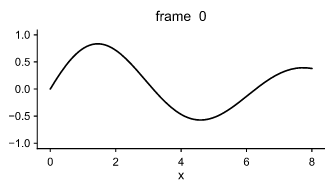

In [2]:
def wave(i):
    """A traveling wave: frame i is the same plot, phase-shifted."""
    phase = 2 * math.pi * i / 24
    fig, ax = pp.subplots(figsize=(240, 140))
    ax.line(xs, [math.sin(x - phase) * math.exp(-0.12 * x) for x in xs])
    ax.set(title=f"frame {i:2d}", xlabel="x", ylim=(-1.1, 1.1))
    return fig


animation = pp.animate(wave, 24, fps=12)
animation.save(OUT / "wave.gif")
print(repr(animation), "→", kb(OUT / "wave.gif"))
animation

## Frames are a count, or the values themselves

`frames` is either an `int` — the callback receives `0 … frames-1` — or any
iterable, whose items are passed through in order. The second form is the one
worth remembering: it lets the animation be driven by the data rather than by
an index, so the callback never has to translate a frame number back into the
thing it stands for.

<Animation 24 frames @ 8 fps>


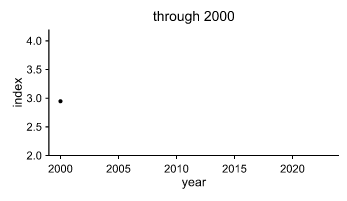

In [3]:
series = [(2000 + k, 3.0 + 0.6 * math.sin(k * 0.55) + random.uniform(-0.15, 0.15))
          for k in range(24)]


def through(year):
    """One frame per year, drawing the series up to that year."""
    shown = [(y, v) for y, v in series if y <= year]
    fig, ax = pp.subplots(figsize=(250, 145))
    ax.line([y for y, _ in shown], [v for _, v in shown], marker="o", markersize=3)
    ax.set(xlim=(1999, 2024), ylim=(2.0, 4.2), title=f"through {year}",
           xlabel="year", ylabel="index")
    return fig


by_year = pp.animate(through, [y for y, _ in series], fps=8)
print(repr(by_year))
by_year

## fps, and whether it loops

`fps` is set at construction and can be overridden per save. `repeat=False`
plays through once and stops on the last frame, which is what you want for a
build-up like the one above and not for a loop like the wave.

In [4]:
once = pp.animate(through, [y for y, _ in series], fps=8, repeat=False)
print(repr(once))

# `fps` at save time wins over the one given at construction.
for rate in (4, 8, 24):
    once.save(OUT / f"series-{rate}fps.gif", fps=rate, dpi=80)
    print(f"  fps={rate:<3} {kb(OUT / f'series-{rate}fps.gif'):>9}  "
          f"{len(once) / rate:.1f} s of playback")

<Animation 24 frames @ 8 fps, once>
  fps=4     69.4 KB  6.0 s of playback
  fps=8     69.4 KB  3.0 s of playback
  fps=24    69.4 KB  1.0 s of playback


The file size barely moves: the frame rate is one delay field per frame, not
more pixels. What changes is how long the same bytes take to play.

## GIF or APNG

`.gif` quantizes each frame to at most 256 colors and plays anywhere. `.apng`
keeps full 8-bit-per-channel color; `.png` means the same thing, because a
multi-frame PNG *is* an APNG (a viewer that does not know the format shows
frame 0).

Which one is smaller depends entirely on the figure, and it is worth measuring
rather than guessing:

In [5]:
N = 40


def field(i):
    """A colormapped field: smooth gradients, thousands of distinct colors."""
    phase = 2 * math.pi * i / 12
    z = [[math.sin(0.3 * c + phase) * math.cos(0.3 * r) for c in range(N)]
         for r in range(N)]
    fig, ax = pp.subplots(figsize=(150, 140))
    ax.imshow(z, cmap="twilight", vmin=-1, vmax=1)
    ax.axis("off")
    return fig


smooth = pp.animate(field, 12, fps=10)

print(f"{'':<22}{'.gif':>10}{'.apng':>10}")
for name, anim in (("a line plot", animation), ("a colormapped field", smooth)):
    sizes = []
    for ext in ("gif", "apng"):
        anim.save(OUT / f"{name.split()[-1]}.{ext}", dpi=100)
        sizes.append(kb(OUT / f"{name.split()[-1]}.{ext}"))
    print(f"{name:<22}{sizes[0]:>10}{sizes[1]:>10}")

                            .gif     .apng
a line plot              63.3 KB  120.2 KB


a colormapped field     221.4 KB  181.3 KB


A line plot has few enough distinct colors that 256 is not a constraint, so
GIF's per-frame palette costs almost nothing and the quantization is
near-lossless — it wins on both counts there. A colormapped field has thousands
of colors, so GIF has to throw most of them away *and* still pays for the
palette, while APNG stays exact and comes out smaller. Reach for `.gif` by
default, and `.apng` for anything with a smooth gradient in it.

The animation below is the field, quantized — inline display is always GIF,
because `image/gif` is the one animated format every notebook frontend plays.

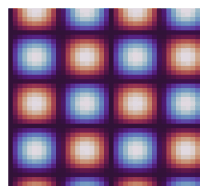

In [6]:
smooth

## dpi

`dpi` sets the raster resolution, and it defaults to **100** rather than
`Figure.save`'s 200: an animation is many frames, and the cost is paid once per
frame in both time and bytes.

In [7]:
print(f"{'dpi':>5}{'pixels':>14}{'size':>12}{'encode':>10}")
for dpi in (50, 100, 200, 300):
    start = time.perf_counter()
    animation.save(OUT / f"wave-{dpi}.gif", dpi=dpi)
    elapsed = time.perf_counter() - start
    w, h = (round(240 * dpi / 72), round(140 * dpi / 72))
    print(f"{dpi:>5}{f'{w}×{h}':>14}{kb(OUT / f'wave-{dpi}.gif'):>12}"
          f"{f'{elapsed * 1000:.0f} ms':>10}")

  dpi        pixels        size    encode


   50        167×97     47.6 KB     10 ms
  100       333×194     63.3 KB     26 ms


  200       667×389    133.8 KB     79 ms


  300      1000×583    216.4 KB    157 ms


## When the destination is not a file

`to_bytes` is the primitive `save` is built on. Reach for it when what you have
is not a path — an HTTP response, a zip member, a `BytesIO` — and use `save`
otherwise, since `save` never holds the encoded animation and the file at once.

In [8]:
data = animation.to_bytes("gif", dpi=80)
print(f"{len(data) / 1024:.1f} KB in memory, starting {data[:6]!r}")

buffer = io.BytesIO(data)
print("as a file object:", buffer.getbuffer().nbytes, "bytes")

# Which also solves the double-render below: encode once, write it twice.
(OUT / "from-bytes.gif").write_bytes(data)
print("written by hand :", kb(OUT / "from-bytes.gif"))

57.2 KB in memory, starting b'GIF89a'
as a file object: 58569 bytes
written by hand : 57.2 KB


## Three rules the API enforces

**Every frame is the same size.** The animation canvas is fixed, so a callback
that returns a differently-sized figure halfway through raises rather than
silently cropping or rescaling it.

**`render` runs once per frame per save.** Saving two formats from one
`Animation` builds every figure twice, and a callback that draws on random
numbers would not even build the same one twice. Encode once with `to_bytes`
when that matters.

**Only GIF and APNG.** There is no video encoder in the package and no ffmpeg
to find on the machine.

In [9]:
def growing(i):
    fig, ax = pp.subplots(figsize=(200 + 10 * i, 140))
    ax.line([0, 1], [0, 1])
    return fig


for description, thunk in [
    ("a frame of a different size", lambda: pp.animate(growing, 3).to_bytes("gif")),
    ("a format with no encoder", lambda: animation.to_bytes("mp4")),
    ("a callback that returns something else", lambda: pp.animate(lambda i: 42, 2).to_bytes("gif")),
    ("no frames at all", lambda: pp.animate(wave, 0)),
]:
    try:
        thunk()
    except (ValueError, TypeError) as exc:
        print(f"{description}\n    {type(exc).__name__}: {exc}\n")

a frame of a different size
    ValueError: every animation frame must have the same size; got (210.0, 140.0) after (200.0, 140.0)

a format with no encoder
    ValueError: unsupported animation format 'mp4'; use apng or gif

a callback that returns something else
    TypeError: render(value) must return a pyplotrs.Figure, got int

no frames at all
    ValueError: frames must be a positive int



In [10]:
calls = []


def counted(i):
    calls.append(i)
    return wave(i)


twice = pp.animate(counted, 6)
twice.save(OUT / "twice.gif", dpi=60)
twice.save(OUT / "twice.apng", dpi=60)
print(f"two saves of a 6-frame animation → {len(calls)} calls to render")

calls.clear()
shared = twice.to_bytes("gif", dpi=60)
(OUT / "once-a.gif").write_bytes(shared)
(OUT / "once-b.gif").write_bytes(shared)
print(f"one to_bytes, written twice     → {len(calls)} calls to render")

two saves of a 6-frame animation → 12 calls to render
one to_bytes, written twice     → 6 calls to render


## Making one readable

### Pin the limits

This is the mistake worth making once. If every frame autoscales to its own
data, the axes move under the curve and the animation reads as a camera
wobbling rather than as a signal changing. Both panels below show the same
growing series; only the right one is legible.

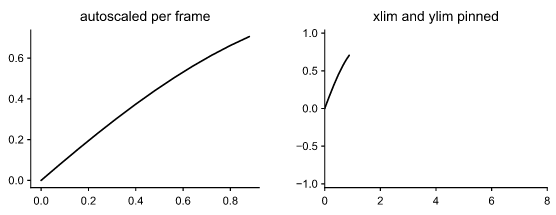

In [11]:
def limits(i):
    n = 12 + 4 * i
    x = xs[:n]
    y = [math.sin(v) * math.exp(-0.1 * v) for v in x]

    fig, axs = pp.subplots(1, 2, figsize=(400, 155))
    axs[0].line(x, y)
    axs[0].set(title="autoscaled per frame")
    axs[1].line(x, y)
    axs[1].set(title="xlim and ylim pinned", xlim=(0, 8), ylim=(-1.05, 1.05))
    return fig


pp.animate(limits, 18, fps=10)

### Move the window, not the data

The other shape an animation takes: the series is fixed and the *view* travels
over it. `set(xlim=...)` per frame is the whole trick, and pinning `ylim` keeps
the vertical scale from breathing.

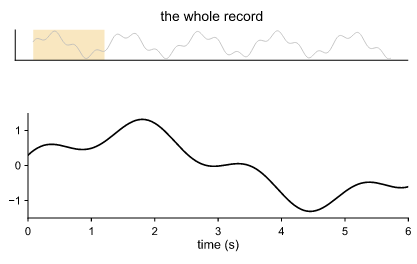

In [12]:
signal = [math.sin(v) + 0.35 * math.sin(3.7 * v + 1.0) for v in
          [i * 0.05 for i in range(601)]]
tt = [i * 0.05 for i in range(601)]


def window(i):
    left = i * 0.55
    fig, axs = pp.subplots(2, 1, figsize=(300, 190), height_ratios=[1, 2])
    axs[0].line(tt, signal, linewidth=0.6, color="#bbb")
    axs[0].axvspan(left, left + 6.0, alpha=0.25, color="C1")
    axs[0].set(title="the whole record", xticks=[], yticks=[])
    axs[1].line(tt, signal)
    axs[1].set(xlim=(left, left + 6.0), ylim=(-1.5, 1.5), xlabel="time (s)")
    return fig


pp.animate(window, 30, fps=12)

### Spin a 3D view

A 3D axes takes `azim` and `elev` through the same `set` as everything else, so
rotating one is a frame index times a step. This is the animation that most
often earns its keep: a surface read from one angle hides what it does from
another.

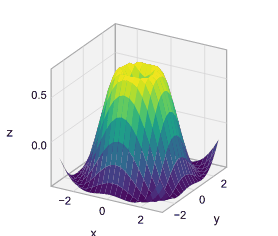

In [13]:
S = 21
gx = [[-3.0 + 6.0 * j / (S - 1) for j in range(S)] for _ in range(S)]
gy = [[-3.0 + 6.0 * i / (S - 1) for _ in range(S)] for i in range(S)]
gz = [[math.sin(math.hypot(x, y) * 1.4) * math.exp(-0.25 * math.hypot(x, y))
       for x, y in zip(row_x, row_y)] for row_x, row_y in zip(gx, gy)]


def spin(i):
    fig = pp.figure(figsize=(200, 170))
    ax = fig.add_subplot(fig.add_gridspec(1, 1)[0, 0], projection="3d")
    ax.surface(gx, gy, gz, cmap="viridis")
    ax.set(azim=-60 + 15 * i, elev=24, xlabel="x", ylabel="y", zlabel="z")
    return fig


pp.animate(spin, 24, fps=12)

For a 3D view specifically, weigh this against `fig.save("...html")`, which
writes an interactive viewer the reader can spin themselves — one file, no
network, and no decision on your part about which angles matter.

## Inline display, and its ceiling

Displaying an animation renders it as a GIF at 100 dpi and base64-encodes it
into the `.ipynb`. That is a real cost: an animation is a still figure times
its frame count, in a file you may well commit. Over **20 MB** it raises rather
than quietly dropping frames the way matplotlib's `animation.embed_limit` does
— a truncated animation and no exception is the worse failure.

Displaying also calls `render` once per frame, exactly as saving does, so a
callback with side effects runs again on every echo.

In [14]:
LIMIT = 20 * 1024 * 1024

one_frame = len(pp.animate(wave, 1).to_bytes("gif", dpi=100))
print(f"one frame at 100 dpi ≈ {one_frame / 1024:.1f} KB")
print(f"the 24-frame wave    ≈ {len(animation.to_bytes('gif', dpi=100)) / 1024:.1f} KB")
print(f"the 20 MB ceiling is ≈ {LIMIT / one_frame:.0f} frames of this figure")
print("\nover that, `save(...)` at your own dpi is the way out.")

one frame at 100 dpi ≈ 2.6 KB


the 24-frame wave    ≈ 63.3 KB
the 20 MB ceiling is ≈ 7730 frames of this figure

over that, `save(...)` at your own dpi is the way out.


## What it costs

Building a figure per frame is cheap enough that the frame count, not the
callback, is what you budget for.

In [15]:
for label, anim, dpi in [("2D line, 240×140 pt", animation, 100),
                         ("2D line, 240×140 pt", animation, 200),
                         ("3D surface, 200×170 pt", pp.animate(spin, 24), 100)]:
    start = time.perf_counter()
    anim.to_bytes("gif", dpi=dpi)
    elapsed = time.perf_counter() - start
    print(f"{label:<26}dpi={dpi:<5}{len(anim)} frames in {elapsed * 1000:6.0f} ms"
          f"  ({len(anim) / elapsed:5.0f} frames/s)")

2D line, 240×140 pt       dpi=100  24 frames in     22 ms  ( 1075 frames/s)
2D line, 240×140 pt       dpi=200  24 frames in     73 ms  (  330 frames/s)
3D surface, 200×170 pt    dpi=100  24 frames in     56 ms  (  430 frames/s)


Those numbers are from the machine that built this notebook and will differ on
yours; the shape is what travels. They are as low as they are because the work
splits cleanly in two. Your callback runs frame by frame in Python, building a
figure and recording its marks; then **every frame is rasterized in parallel
across cores with the GIL released** — for a GIF, the palette quantization too,
which is the expensive half. So the callback is the part you can make slow, and
the renderer is the part that already uses the machine.

The same GIL-releasing property applied to a batch of *still* figures — and
the export speed all of this rests on — is
[output formats and performance](08_output_and_performance.ipynb).

## What to reach for

| You want | Write |
|---|---|
| A frame per index | `pp.animate(render, 60)` |
| A frame per data value | `pp.animate(render, timestamps)` |
| A loop | the default, `repeat=True` |
| A build-up that stops at the end | `repeat=False` |
| Something that plays anywhere | `.gif` |
| Smooth gradients, exact color | `.apng` |
| A different rate for one save | `save(..., fps=...)` |
| Bytes instead of a file | `to_bytes("gif", dpi=...)` |
| Two formats without rendering twice | one `to_bytes`, then write it |
| A 3D view the reader can steer | not an animation — `fig.save("v.html")` |

**Next:** [output formats and performance](08_output_and_performance.ipynb) —
what each of the still formats guarantees, and how fast it is written.